输出目录: results_rolling/

Step 1: 加载数据
数据维度: (59146, 113)
时间范围: 2019-07-01 13:25:00 ~ 2021-06-30 23:55:00
特征数: 102
总正样本: 2565 (4.34%)

Step 2: Walk-forward validation

  Fold 1
    Train: 2019-07-01 ~ 2020-03-31 (16,990 samples, pos=2.75%)
    Test:  2020-04-01 ~ 2020-06-30 (6,546 samples, pos=2.99%)
    PR-AUC: 0.3764 | ROC-AUC: 0.7973 | 12.6× baseline

  Fold 2
    Train: 2019-07-01 ~ 2020-06-30 (23,631 samples, pos=2.84%)
    Test:  2020-07-01 ~ 2020-09-30 (6,945 samples, pos=2.89%)
    PR-AUC: 0.3422 | ROC-AUC: 0.7439 | 11.8× baseline

  Fold 3
    Train: 2019-07-01 ~ 2020-09-30 (30,668 samples, pos=2.86%)
    Test:  2020-10-01 ~ 2020-12-31 (8,600 samples, pos=3.69%)
    PR-AUC: 0.3408 | ROC-AUC: 0.7317 | 9.2× baseline

  Fold 4
    Train: 2019-07-01 ~ 2020-12-31 (39,371 samples, pos=3.05%)
    Test:  2021-01-01 ~ 2021-01-25 (2,133 samples, pos=6.05%)
    PR-AUC: 0.3805 | ROC-AUC: 0.7748 | 6.3× baseline

  Main (Holdout)
    Train: 2019-07-01 ~ 2021-01-25 (41,637 samples, pos=3.21%)


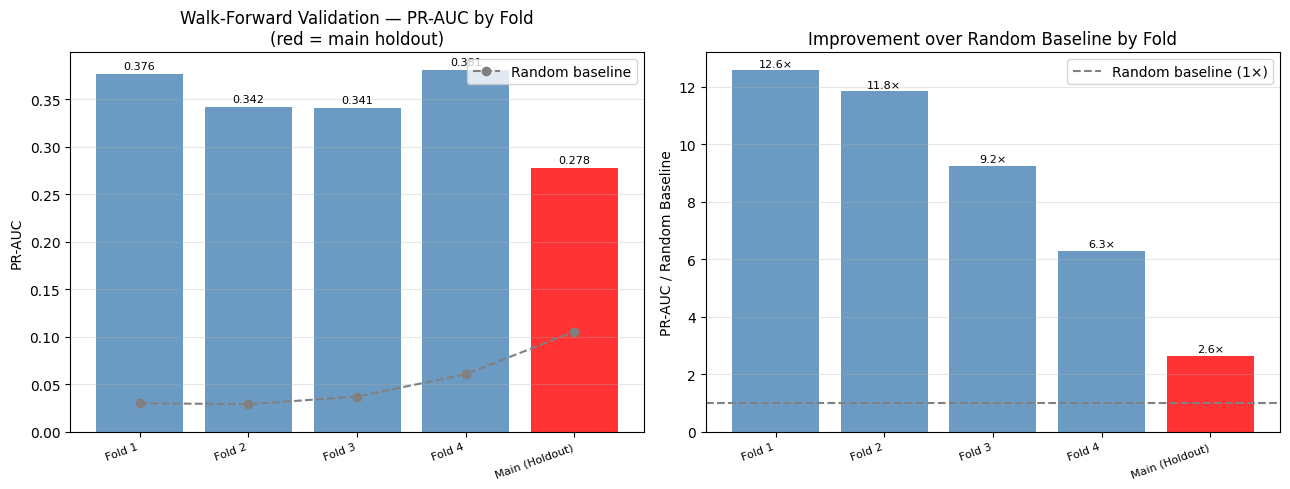

✓ 保存: results_rolling/rolling_validation.png

ROLLING VALIDATION COMPLETE

  Fold 1-4 PR-AUC: 0.3600 ± 0.0214
  Main holdout PR-AUC: 0.2780

  ✓ January peak preserved as true holdout throughout


In [3]:
"""
Rolling-Origin Walk-Forward Validation
=======================================
用滚动扩展窗口验证模型稳定性，January peak作为真正holdout

折数设计:
  Fold 1: Train 2019-07 ~ 2020-03  | Test 2020-04 ~ 2020-06
  Fold 2: Train 2019-07 ~ 2020-06  | Test 2020-07 ~ 2020-09
  Fold 3: Train 2019-07 ~ 2020-09  | Test 2020-10 ~ 2020-12
  Fold 4: Train 2019-07 ~ 2020-12  | Test 2021-01-01 ~ 2021-01-25
  Main:   Train 2019-07 ~ 2021-01-25 | Test 2021-01-28 ~ 2021-02-28 (主实验holdout)

输入: data/merged_data_scaled_CLEAN.parquet
      data/feature_groups_CLEAN.json
输出: results_rolling/
"""

import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score
)

# ── 配置 ──────────────────────────────────────────────────────────────────────
DATA_FILE   = 'data/merged_data_scaled_CLEAN.parquet'
GROUPS_FILE = 'data/feature_groups_CLEAN.json'
TARGET      = 'EWS_15min'
RANDOM_SEED = 42

LEAKAGE_FEATURES = [
    'is_episode_t', 'is_luld', 'is_anomaly',
    'is_price_spike', 'is_volume_surge',
    'thread_concentration', 'is_official_halt',
]

LGB_PARAMS = {
    'max_depth': 6,
    'learning_rate': 0.05,
    'n_estimators': 300,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_samples': 20,
    'random_state': RANDOM_SEED,
    'n_jobs': -1,
    'verbose': -1,
}

# Walk-forward折数定义
FOLDS = [
    {'name': 'Fold 1', 'train_end': '2020-03-31', 'test_start': '2020-04-01', 'test_end': '2020-06-30'},
    {'name': 'Fold 2', 'train_end': '2020-06-30', 'test_start': '2020-07-01', 'test_end': '2020-09-30'},
    {'name': 'Fold 3', 'train_end': '2020-09-30', 'test_start': '2020-10-01', 'test_end': '2020-12-31'},
    {'name': 'Fold 4', 'train_end': '2020-12-31', 'test_start': '2021-01-01', 'test_end': '2021-01-25'},
    {'name': 'Main (Holdout)', 'train_end': '2021-01-25', 'test_start': '2021-01-28', 'test_end': '2021-02-28'},
]

TRAIN_START = '2019-07-01'

OUT_DIR = 'results_rolling'
os.makedirs(OUT_DIR, exist_ok=True)
print(f'输出目录: {OUT_DIR}/')

# ── 1. 加载数据 ────────────────────────────────────────────────────────────────
print('\n' + '='*65)
print('Step 1: 加载数据')
print('='*65)

df = pd.read_parquet(DATA_FILE)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

with open(GROUPS_FILE, 'r', encoding='utf-8') as f:
    feature_groups = json.load(f)

# 特征构建与主模型完全一致
FULL_GROUPS = ['market', 'cascade', 'network', 'temporal', 'text',
               'burstiness', 'user_overlap', 'text_duplication']

def get_features(groups_list):
    feats = []
    for g in groups_list:
        feats.extend(feature_groups.get(g, []))
    feats = [f for f in dict.fromkeys(feats) if f in df.columns]
    feats = [f for f in feats if f not in LEAKAGE_FEATURES]
    return feats

all_features = get_features(FULL_GROUPS)

print(f'数据维度: {df.shape}')
print(f'时间范围: {df["timestamp"].min()} ~ {df["timestamp"].max()}')
print(f'特征数: {len(all_features)}')
print(f'总正样本: {int(df[TARGET].sum())} ({df[TARGET].mean()*100:.2f}%)')

# ── 2. Walk-forward循环 ────────────────────────────────────────────────────────
print('\n' + '='*65)
print('Step 2: Walk-forward validation')
print('='*65)

results = []

for fold in FOLDS:
    name       = fold['name']
    train_end  = fold['train_end']
    test_start = fold['test_start']
    test_end   = fold['test_end']

    # 数据切割
    train_mask = (df['timestamp'] >= TRAIN_START) & (df['timestamp'] <= train_end)
    test_mask  = (df['timestamp'] >= test_start)  & (df['timestamp'] <= test_end)

    X_train = df.loc[train_mask, all_features].fillna(0)
    y_train = df.loc[train_mask, TARGET]
    X_test  = df.loc[test_mask,  all_features].fillna(0)
    y_test  = df.loc[test_mask,  TARGET]

    # 跳过正样本为0的折
    if y_train.sum() == 0 or y_test.sum() == 0:
        print(f'\n  {name}: 跳过（正样本不足）')
        continue

    spw = (y_train == 0).sum() / y_train.sum()

    # 训练
    model = lgb.LGBMClassifier(**LGB_PARAMS, class_weight={0: 1, 1: spw})
    model.fit(X_train, y_train)

    # 预测
    y_prob = model.predict_proba(X_test)[:, 1]

    # 指标
    pr_auc         = average_precision_score(y_test, y_prob)
    roc_auc        = roc_auc_score(y_test, y_prob)
    random_baseline = y_test.mean()

    # 最优阈值F1
    thresholds = np.arange(0.02, 0.70, 0.01)
    f1s    = [f1_score(y_test, (y_prob >= t).astype(int), zero_division=0)
              for t in thresholds]
    best_t = thresholds[np.argmax(f1s)]
    y_pred = (y_prob >= best_t).astype(int)

    result = {
        'fold':             name,
        'train_period':     f'{TRAIN_START} ~ {train_end}',
        'test_period':      f'{test_start} ~ {test_end}',
        'train_samples':    int(train_mask.sum()),
        'test_samples':     int(test_mask.sum()),
        'train_pos_rate':   round(y_train.mean(), 4),
        'test_pos_rate':    round(y_test.mean(), 4),
        'random_baseline':  round(random_baseline, 4),
        'pr_auc':           round(pr_auc, 4),
        'roc_auc':          round(roc_auc, 4),
        'improvement':      round(pr_auc / random_baseline, 2),
        'best_threshold':   round(best_t, 2),
        'f1':               round(f1_score(y_test, y_pred, zero_division=0), 4),
        'precision':        round(precision_score(y_test, y_pred, zero_division=0), 4),
        'recall':           round(recall_score(y_test, y_pred, zero_division=0), 4),
    }

    results.append(result)

    print(f'\n  {name}')
    print(f'    Train: {TRAIN_START} ~ {train_end} ({train_mask.sum():,} samples, pos={y_train.mean()*100:.2f}%)')
    print(f'    Test:  {test_start} ~ {test_end} ({test_mask.sum():,} samples, pos={y_test.mean()*100:.2f}%)')
    print(f'    PR-AUC: {pr_auc:.4f} | ROC-AUC: {roc_auc:.4f} | {pr_auc/random_baseline:.1f}× baseline')

# ── 3. 汇总结果 ────────────────────────────────────────────────────────────────
print('\n' + '='*65)
print('Step 3: 汇总结果')
print('='*65)

results_df = pd.DataFrame(results)
print('\n' + results_df[['fold', 'test_period', 'pr_auc', 'roc_auc',
                          'random_baseline', 'improvement']].to_string(index=False))

# 统计（排除Main holdout）
rolling_folds = results_df[results_df['fold'] != 'Main (Holdout)']
main_fold     = results_df[results_df['fold'] == 'Main (Holdout)']

print(f'\n  Rolling folds (Fold 1-4):')
print(f'    PR-AUC mean: {rolling_folds["pr_auc"].mean():.4f}')
print(f'    PR-AUC std:  {rolling_folds["pr_auc"].std():.4f}')
print(f'    PR-AUC range: {rolling_folds["pr_auc"].min():.4f} ~ {rolling_folds["pr_auc"].max():.4f}')

if len(main_fold) > 0:
    print(f'\n  Main holdout (Jan 28 - Feb 28):')
    print(f'    PR-AUC: {main_fold["pr_auc"].values[0]:.4f}')

results_df.to_csv(f'{OUT_DIR}/rolling_validation_results.csv', index=False)
print(f'\n✓ 保存: {OUT_DIR}/rolling_validation_results.csv')

# ── 4. 可视化 ──────────────────────────────────────────────────────────────────
print('\nStep 4: 可视化')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# PR-AUC across folds
colors = ['steelblue'] * (len(results_df) - 1) + ['red']
bars = axes[0].bar(range(len(results_df)), results_df['pr_auc'],
                   color=colors, alpha=0.8)
axes[0].plot(range(len(results_df)), results_df['random_baseline'],
             'gray', linestyle='--', marker='o', lw=1.5, label='Random baseline')
axes[0].set_xticks(range(len(results_df)))
axes[0].set_xticklabels(results_df['fold'], rotation=20, ha='right', fontsize=8)
axes[0].set_ylabel('PR-AUC')
axes[0].set_title('Walk-Forward Validation — PR-AUC by Fold\n(red = main holdout)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, results_df['pr_auc']):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=8)

# PR-AUC vs random baseline improvement
axes[1].bar(range(len(results_df)), results_df['improvement'],
            color=colors, alpha=0.8)
axes[1].axhline(y=1, color='gray', linestyle='--', lw=1.5, label='Random baseline (1×)')
axes[1].set_xticks(range(len(results_df)))
axes[1].set_xticklabels(results_df['fold'], rotation=20, ha='right', fontsize=8)
axes[1].set_ylabel('PR-AUC / Random Baseline')
axes[1].set_title('Improvement over Random Baseline by Fold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
for i, val in enumerate(results_df['improvement']):
    axes[1].text(i, val + 0.05, f'{val:.1f}×', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/rolling_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ 保存: {OUT_DIR}/rolling_validation.png')

print('\n' + '='*65)
print('ROLLING VALIDATION COMPLETE')
print('='*65)
print(f'\n  Fold 1-4 PR-AUC: {rolling_folds["pr_auc"].mean():.4f} ± {rolling_folds["pr_auc"].std():.4f}')
print(f'  Main holdout PR-AUC: {main_fold["pr_auc"].values[0]:.4f}')
print(f'\n  ✓ January peak preserved as true holdout throughout')